In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix)
import sys
import os
sys.path.append(os.path.abspath(".."))

In [2]:
model = joblib.load("../models/trained_model.pkl")
vectorizer = joblib.load("../models/vectorizer.pkl")


In [3]:
data = pd.read_csv("../data/processed/preprocessed_toxicity_dataset.csv")
data.head()

,text,label,clean_text,processed_text
0,"""\n""""On articles about topics with many fansit...",0,on articles about topics with many fansites in...,article topic many fansites including link one...
1,~I heard that Dick Gephardt was actually presi...,0,i heard that dick gephardt was actually presid...,heard dick gephardt actually president miami d...
2,The magnesium stress connection doesn't have a...,0,the magnesium stress connection doesnt have a ...,magnesium stress connection doesnt reference c...
3,This ain't no mf http://t.co/dOOeogiROg bitch ...,1,this aint no mf bitch ass,aint mf bitch as
4,&#8220;@ZvckSlvt3r704: My sister shittin on yo...,1,zvckslvtr my sister shittin on you hos once ag...,zvckslvtr sister shittin ho vsamone wodeh bout...


In [4]:
data = data.dropna(subset=["processed_text"])
data["processed_text"].isna().sum()

0

In [5]:
X = data["processed_text"]
y = data["label"]

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [7]:
X_test_tfidf = vectorizer.transform(X_test)

In [8]:
y_pred = model.predict(X_test_tfidf)
y_pred[:10]

array([1, 0, 0, 1, 1, 1, 1, 1, 1, 1], dtype=int64)

In [9]:
accuracy = accuracy_score(y_test, y_pred)
print("model Accuracy:", accuracy)

model Accuracy: 0.919959266802444


In [10]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.96      0.92      7293
           1       0.95      0.88      0.92      7437

    accuracy                           0.92     14730
   macro avg       0.92      0.92      0.92     14730
weighted avg       0.92      0.92      0.92     14730



In [11]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[6982,  311],
       [ 868, 6569]], dtype=int64)

In [12]:
results = pd.DataFrame({"text": X_test,"true_label": y_test,"predicted_label": y_pred})
false_positives = results[(results.true_label == 0) & (results.predicted_label == 1)]
false_negatives = results[(results.true_label == 1) & (results.predicted_label == 0)]
false_positives.head()

,text,true_label,predicted_label
71749,richard wang dear richard wang department offe...,0,1
49294,fucking synths name,0,1
57985,the— the— wait would—fuck i’m,0,1
7005,smh rt dailymail nyc cop leave ebola doctor ap...,0,1
72654,im talking issue know tried ruin want resoluti...,0,1


In [13]:
feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]
top_toxic = np.argsort(coefficients)[-20:]
for i in top_toxic:
    print(feature_names[i])

moron
niggah
retarded
bullshit
suck
nigger
fag
cunt
dick
asshole
stupid
as
fucking
faggot
shit
idiot
fuck
pussy
hoe
bitch


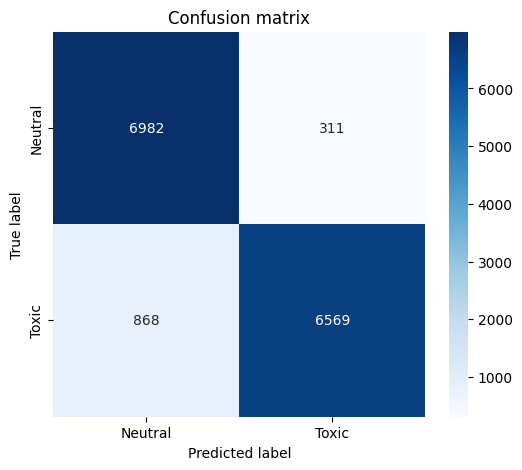

In [14]:
from src.visualizations.plot_metrics import plot_confusion_matrix
plot_confusion_matrix(
    y_test,
    y_pred,
    save_path="../reports/figures/confusion_matrix.png"
)

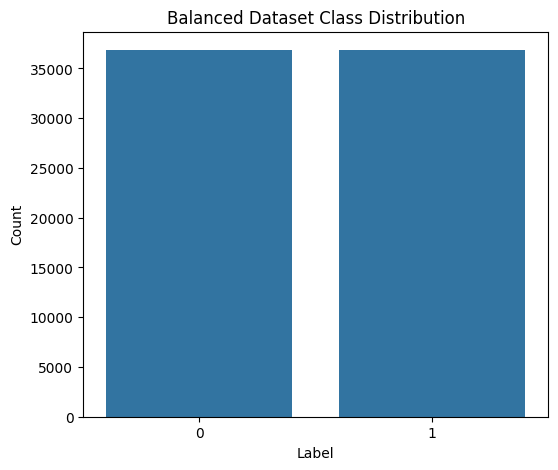

In [15]:
from src.visualizations.plot_metrics import plot_class_distribution
plot_class_distribution(
    y,
    save_path="../reports/figures/class_distribution.png")

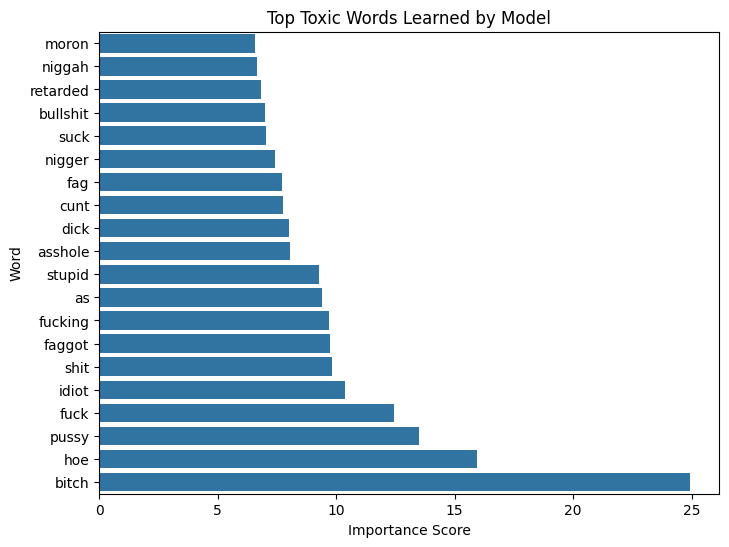

In [16]:
from src.visualizations.plot_metrics import plot_top_toxic_words
plot_top_toxic_words(
    model,
    vectorizer,
    save_path="../reports/figures/toxic_feature_importance.png"
)